In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import lightkurve as lk
import numpy as np
from scipy.optimize import least_squares
from astropy import units as u
from astropy import constants as const
from astroquery.mast import Catalogs
import batman
import radvel
from dace_query.spectroscopy import Spectroscopy

2026-08-22 20:15:21,206 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


### Transit Method

In [2]:
render_plots = True

In [3]:
input_catalog = input('input catalog: ').upper()
split = input_catalog.split(' ')
telescope = split[0]

if telescope == 'TIC':
    author = 'SPOC'
if telescope == 'KIC':
    author = 'Kepler'

try:
    star = Catalogs.query_object(input_catalog, catalog = 'TIC') 
    star_Teff = star['Teff'][0]
    star_lumclass = str(star['lumclass'][0]).capitalize()
    if star_Teff >= 33000:
        stellar_class = str(f'O-Type Blue {star_lumclass}')
    elif star_Teff >= 10000:
        stellar_class = str(f'B-Type Blue/White {star_lumclass}')
    elif star_Teff >= 7300:
        stellar_class = str(f'A-Type White {star_lumclass}')
    elif star_Teff >= 6000:
        stellar_class = str(f'F-Type White/Yellow {star_lumclass}')
    elif star_Teff >= 5300:
        stellar_class = str(f'G-Type Yellow {star_lumclass}')
    elif star_Teff >= 3900:
        stellar_class = str(f'K-Type Orange {star_lumclass}')
    elif star_Teff >= 2300:
        stellar_class = str(f'M-Type Red {star_lumclass}')
    else:
        stellar_class = 'Brown Dwarf'  
    print(f'Stellar Class: {stellar_class}')
except:
    print('MAST import error: try again')

input catalog:  TIC 266980320


Stellar Class: G-Type Yellow Dwarf


In [4]:
star_Teff = star['Teff'][0]
star_lumclass = str(star['lumclass'][0]).capitalize()

In [5]:
automate_data_cell = True

In [6]:
def import_tess(input_catalog, author, all_data, years):    
    sectors_list = []
    for sector in all_data.table:
        sectors_list.append(int(sector['sequence_number']))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:           
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
        
    print('\nselected data:')
    print(selected_data)        
    return raw_ts, sectors_list, selected_data

def import_kepler(input_catalog, author, all_data, years):    
    quarters_list = []
    for quarter in all_data.table:
        quarters_list.append(int(quarter['mission'].split(' ')[2]))

    if years == 0:
        yr_range, year_mask = limit_range(all_data)
        if yr_range > 5:            
            selected_data = all_data[year_mask]
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()
        else:
            selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
            raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list).download_all()
    else:
        year_mask = (all_data.table['year'] >= years[0]) & (all_data.table['year'] <= years[-1])
        selected_data = all_data[year_mask]
        raw_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()

        
    print('\nselected data:')
    print(selected_data)
    return raw_ts, quarters_list, selected_data

def limit_range(all_data):
    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table['year'] >= yr_mode - 2) & (all_data.table['year'] <= yr_mode + 2)
        else:
            year_mask = (all_data.table['year'] >= yr_median - 2) & (all_data.table['year'] <= yr_median + 2)
    else:
        year_mask = all_years
    return yr_range, year_mask

all_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short')
print('all data:')
print(all_data)

if automate_data_cell == True:
    years = 0
    automate_data_cell = False
else:
    years_input = input('Year Range: ')
    years_range = years_input.split('-')
    years_min = int(years_range[0])
    years_max = int(years_range[-1])
    if years_min != years_max:
        years = [years_min]
        i = 1
        while years[-1] != years_max:
            years.append(years_min + i)
            i += 1
    
if telescope == 'TIC':
    raw_ts, sectors, selected_data = import_tess(input_catalog, author, all_data, years)
if telescope == 'KIC':
    raw_ts, quarters, selected_data = import_kepler(input_catalog, author, all_data, years)

all data:
SearchResult containing 8 data products.

 #      mission     year author exptime target_name distance
                                   s                 arcsec 
--- --------------- ---- ------ ------- ----------- --------
  0  TESS Sector 01 2018   SPOC     120   266980320      0.0
  1  TESS Sector 28 2020   SPOC     120   266980320      0.0
  2  TESS Sector 68 2023   SPOC     120   266980320      0.0
  3  TESS Sector 95 2025   SPOC     120   266980320      0.0
  4 TESS Sector 102 2026   SPOC     120   266980320      0.0
  5 TESS Sector 103 2026   SPOC     120   266980320      0.0
  6 TESS Sector 104 2026   SPOC     120   266980320      0.0
  7 TESS Sector 105 2026   SPOC     120   266980320      0.0

selected data:
SearchResult containing 5 data products.

 #      mission     year author exptime target_name distance
                                   s                 arcsec 
--- --------------- ---- ------ ------- ----------- --------
  0  TESS Sector 95 2025   SPOC     

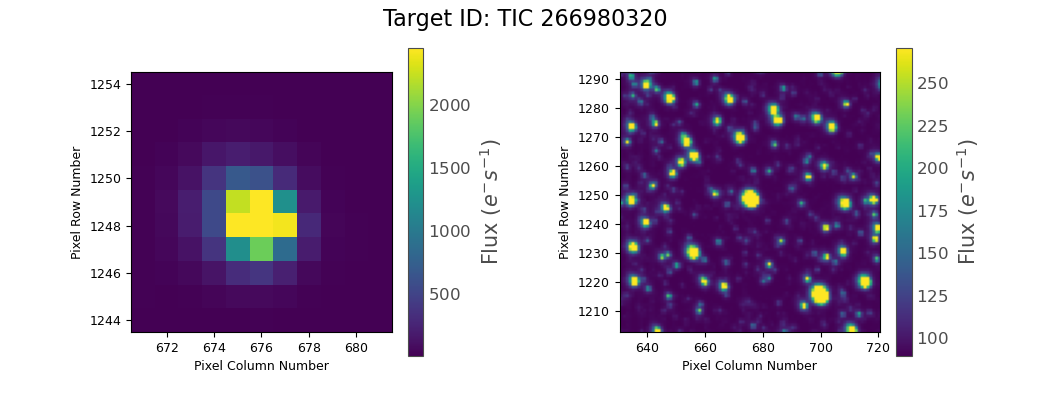

In [7]:
if render_plots == True:
    if telescope == 'TIC':
        fig, (ax1, ax2) = plt.subplots(nrows = 1 ,ncols = 2, figsize = (10.5, 4))
        fig.suptitle(f'Target ID: {input_catalog}', fontsize = 16)
        fig.subplots_adjust(wspace = .5)
        
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', sector = sectors[0]).download()
        px_file.plot(ax = ax1, title = '')
        
        ff_file = lk.search_tesscut(input_catalog, sector = sectors[0]).download(cutout_size = 90)
        ff_file.plot(ax = ax2, title = '')
        
    if telescope == 'KIC':
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', quarter = quarters[0]).download()
        px_file.plot()
        plt.title(f'Target ID: {input_catalog}', fontsize = 16)

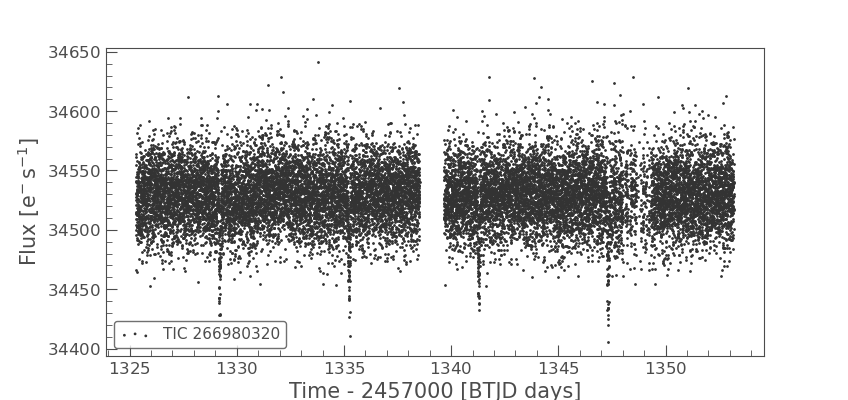

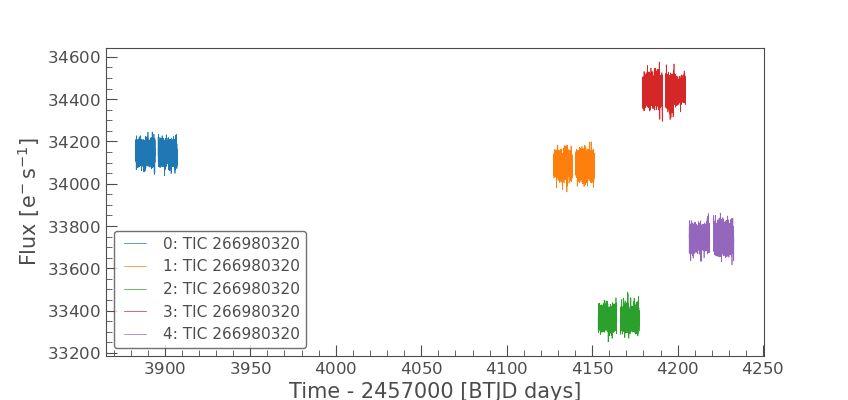

In [8]:
if telescope == 'TIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors[0], limit = 1).download()
    if len(sectors) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if telescope == 'KIC':
    first_ts = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters[0], limit = 1).download()
    if len(quarters) > 1:
        refined_ts = raw_ts.stitch().remove_nans().flatten()
    else:
        first_ts.scatter()
        refined_ts = first_ts.remove_nans().flatten()

if render_plots == True:
    first_ts.scatter()
    raw_ts.plot()

In [9]:
bin_count = 100000
if len(refined_ts) > bin_count:
    bin_width = (np.max(refined_ts.time.value)-np.min(refined_ts.time.value))/(bin_count/.94)
    harmonics_ts = refined_ts.bin(bin_width) 
else:
    harmonics_ts = refined_ts
print(f'Count of points in harmonics test: {len(harmonics_ts)}')

Count of points in harmonics test: 76693


In [10]:
add_period = False

Period: 6.0346 d (SNR: 20.273)


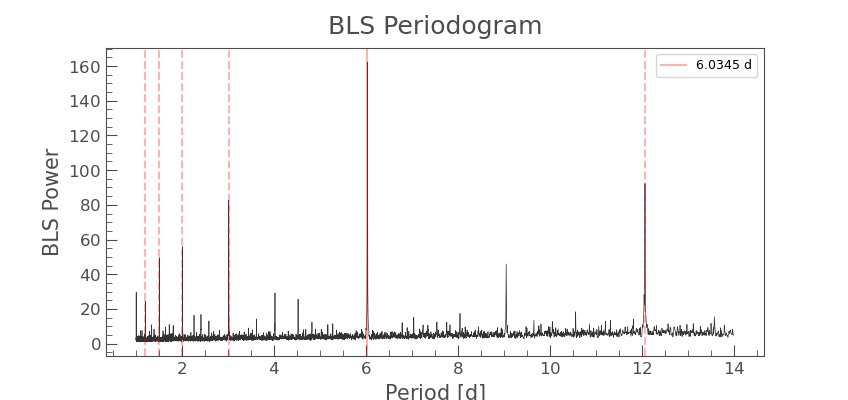

In [11]:
def initial_bls(ts, min_period, max_period):
    search_duration = np.linspace(.05, .3, 10)
    search_period = np.logspace(np.log10(min_period), np.log10(max_period), 5000) 
    initial_periodogram = ts.to_periodogram(method = 'bls', period = search_period, duration = search_duration, frequency_factor = 1000)
    initial_period = initial_periodogram.period_at_max_power
    initial_duration = initial_periodogram.duration_at_max_power  
    return initial_periodogram, initial_period, initial_duration
    
def refine_bls(ts, prev_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(prev_period.value - .1, prev_period.value + .1, 5000)
    refined_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    refined_period = refined_periodogram.period_at_max_power
    refined_duration = refined_periodogram.duration_at_max_power
    refined_time = refined_periodogram.transit_time_at_max_power
    refined_depth = refined_periodogram.depth_at_max_power
    return refined_periodogram, refined_period, refined_duration, refined_time, refined_depth

def search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts):
    harmonics = [refined_period.value]
    i = 2
    while i <= 5:
        harmonics_divide = refined_period.value/i
        harmonics_multiply = refined_period.value*i
        if harmonics_divide >= min_period:
            harmonics.append(harmonics_divide)
        if harmonics_multiply <= max_period:
            harmonics.append(harmonics_multiply)
        i += 1 
    harmonics.sort()
    
    dip_ratio = []
    for each in harmonics:
        folded = harmonics_ts.fold(period = each, epoch_time = refined_time)
        in_transit = np.logical_and((folded.phase.value > -refined_duration.value/3), (folded.phase.value < refined_duration.value/3))
        above_dip = folded.flux.value > 1-refined_depth*(2/3)
        both = np.logical_and(in_transit, above_dip)
        dip_ratio.append(len(folded[both])/len(folded[in_transit]))

        #lim_folded = folded[in_transit]
        #folded.scatter(title = f'index {harmonics.index(each)}: {round(each*u.day,4)}')
        #plt.axhline(1-refined_periodogram.depth_at_max_power*(2/3), color = "green")
        #plt.axvline(-refined_duration.value/3, color = "green")
        #plt.axvline(refined_duration.value/3, color = "green")
        #plt.xlim(-.1,.1)
        #plt.ylim(.9995, 1.0005)
    
    high_freq_h = []
    mean = (dip_ratio[0]+dip_ratio[-1])/2
    
    i = 0
    while i < len(dip_ratio):
        if dip_ratio[i] > mean:
            high_freq_h.append(dip_ratio[i])
        i += 1
    
    transit_index = len(high_freq_h)
    return harmonics, transit_index

def mask_ts(time_series, ts, selected_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(selected_period - .1, selected_period + .1, 5000)
    final_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    final_period = final_periodogram.period_at_max_power
    final_duration = final_periodogram.duration_at_max_power
    final_time = final_periodogram.transit_time_at_max_power
    final_depth = final_periodogram.depth_at_max_power
    
    mask = final_periodogram.get_transit_mask(period = final_period, transit_time = final_time, duration = final_duration*2)
    masked_ts = ts[~mask]
    time_series.append(masked_ts)
    return final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth

def plot_periodogram(periodogram, selected_periods, min_period, max_period):
    periodogram.plot(title = 'BLS Periodogram', label = '_nolegend_')
    
    i = 0
    while i < len(selected_periods):
        if i == 0:
            color = 'red'
        if i == 1:
            color = 'green'
        if i == 2:
            color = 'blue'
        if i == 3:
            color = 'orange'
        if i == 4:
            color = 'purple'
        plt.axvline(selected_periods[i], color = color, alpha = .3)

        labels = []
        for each in selected_periods:
            labels.append(round(each,4)*u.day)
        plt.legend(labels)
        
        x = 2
        while x <= 5:
            harmonics_divide = selected_periods[i]/x
            harmonics_multiply = selected_periods[i]*x
            if harmonics_divide >= min_period:
                plt.axvline(harmonics_divide, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            if harmonics_multiply <= max_period:
                plt.axvline(harmonics_multiply, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            x += 1 
        i += 1

if add_period == False:
    min_period = 1
    max_period = 14
    time_series = [refined_ts]
    cycle = 0
    selected_periods = []
    exoplanets = []
    periods = []
    durations = []
    transit_times = []
    
    while True:
        initial_periodogram, initial_period, initial_duration = initial_bls(time_series[-1], min_period, max_period)
        if cycle == 0:
            first_periodogram = initial_periodogram
        cycle += 1
    
        refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
        if np.max(refined_periodogram.snr) < 10:
            break

        harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
        for each in harmonics:
            if each == harmonics[transit_index]:
                selected_periods.append(each)
        
        final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
        exoplanets.append({
            'stellar_class': stellar_class,
            'period': final_period, 
            'duration': final_duration, 
            'transit_t0': final_time,       
            'depth': final_depth,
            'snr': np.max(final_periodogram.snr)
        }) 
        periods.append(final_period.value)
        durations.append(final_duration.value)
        transit_times.append(final_time.value)
    add_period = True
else:
    refined_periodogram, refined_period, refined_duration, refined_time, refined_depth = refine_bls(time_series[-1], initial_period, initial_duration)
    harmonics, transit_index = search_harmonics(refined_period, refined_depth, min_period, max_period, harmonics_ts)
    for each in harmonics:
        if each == harmonics[transit_index]:
            selected_periods.append(each)
    final_periodogram, time_series, masked_ts, final_period, final_duration, final_time, final_depth = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
    exoplanets.append({
        'stellar_class': stellar_class,
        'period': final_period, 
        'duration': final_duration, 
        'transit_t0': final_time,       
        'depth': final_depth,
        'snr': np.max(final_periodogram.snr)
    }) 
    periods.append(final_period.value)
    durations.append(final_duration.value)
    transit_times.append(final_time.value)  

for each in exoplanets:
    print(f'Period: {round(each["period"],4)} (SNR: {round(each["snr"],4)})')
plot_periodogram(first_periodogram, selected_periods, min_period, max_period)

In [12]:
remove_lc = False

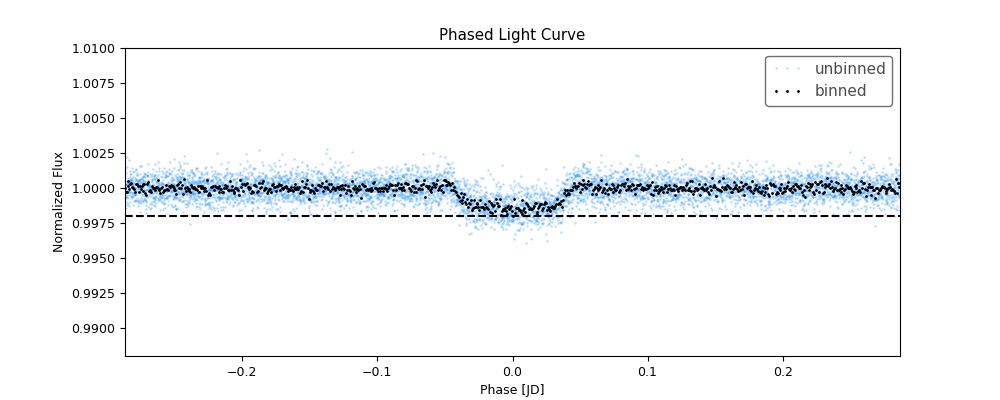

Radius:
5.1058 earthRad
0.4555 jupiterRad


In [13]:
def clean_data(mission, refined_ts):
    transit_mask = refined_ts.create_transit_mask(
                period = periods, 
                transit_time = transit_times, 
                duration = durations
            )
    if len(mission) > 1:
        clean_ts = raw_ts.stitch().remove_nans().flatten(mask = transit_mask)
    else:
        clean_ts = first_ts.remove_nans().flatten(mask = transit_mask)
    return clean_ts

def plot_light_curve(clean_ts, period, t0, duration):
    phased_lc = clean_ts.fold(period = period, epoch_time = t0)
    binned_lc = phased_lc.bin(1/60/24)
    dip = binned_lc.flux.value.min()
    depth = 1 - dip
    half_duration = duration.value/2
    if render_plots == True:
        fig, ax = plt.subplots(figsize = (10,4))
        phased_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "dodgerblue", alpha = .2, label = "unbinned")
        binned_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "black", label = "binned")
        plt.axhline(dip, color = 'black', linestyle = '--')
        plt.title("Phased Light Curve")
        plt.xlim(-(half_duration + .25), (half_duration + .25))
        plt.ylim(dip - .01, 1.01)
        plt.show()
    return depth, binned_lc, phased_lc

def estimate_radius(star, depth):
    exo_sun_rad = np.sqrt(depth) * (star["rad"][0] * u.R_sun)
    exo_earth_rad = exo_sun_rad.to(u.Rearth) 
    exo_jupiter_rad = exo_sun_rad.to(u.Rjupiter) 
    print('Radius:')
    print(round(exo_earth_rad, 4))
    print(round(exo_jupiter_rad, 4))
    return exo_earth_rad

def run_lc_loop(exoplanets, clean_ts):
    for each in exoplanets:
        depth, binned_lc, phased_lc = plot_light_curve(clean_ts, each["period"], each["transit_t0"], each["duration"])
        each["depth"] = depth
    
        transit_event = np.logical_and(binned_lc.phase.value > -0.2, binned_lc.phase.value < 0.2)
        each["light_curve"] = binned_lc[transit_event]
        
        radius = estimate_radius(star, depth)
        each["radius"] = radius

if remove_lc == False:
    if telescope == "TIC":
        clean_ts = clean_data(sectors, refined_ts)
    if telescope == "KIC":
        clean_ts = clean_data(quarters, refined_ts)
        
    run_lc_loop(exoplanets, clean_ts)
    remove_lc = True
else:
    remove_index = int(input('Remove Candidate(s)?'))
    del exoplanets[remove_index]
    run_lc_loop(exoplanets, clean_ts)

In [14]:
def orbital_distance(star, period):
    star_mass = star['mass'][0]* u.M_sun
    star_mass = star_mass.to(u.kg)
    period = period.to(u.s)
    semimajor_axis = np.cbrt((const.G*star_mass*np.square(period))/(4*np.square(np.pi)))
    semimajor_axis = semimajor_axis.to(u.au)
    print(f'Semimajor Axis: {round(semimajor_axis, 4)}') 
    return semimajor_axis

def habitable_zone(star, semimajor_axis):
    star_luminosity = star['lum'][0]*u.L_sun
    inner_lim = np.sqrt(star_luminosity/(1.1*u.L_sun))*u.au
    outer_lim = np.sqrt(star_luminosity/(.53*u.L_sun))*u.au

    if semimajor_axis < inner_lim:
        habitability = 'too hot'
    elif semimajor_axis > outer_lim:
        habitability = 'too cold'
    else:
        habitability = 'just right'
    print(f'Habitability: {habitability}')  
    return habitability

for each in exoplanets:
    semimajor_axis = orbital_distance(star, each['period'])
    each['semimajor_axis'] = semimajor_axis

    habitability = habitable_zone(star, each['semimajor_axis'])
    each['habitability'] = habitability

Semimajor Axis: 0.0642 AU
Habitability: too hot


Radius: 4.4228 earthRad
Inclination: 86.3082 deg
Eccentricity: 0.0
Argument of Periapsis (ω): 47.8176 deg


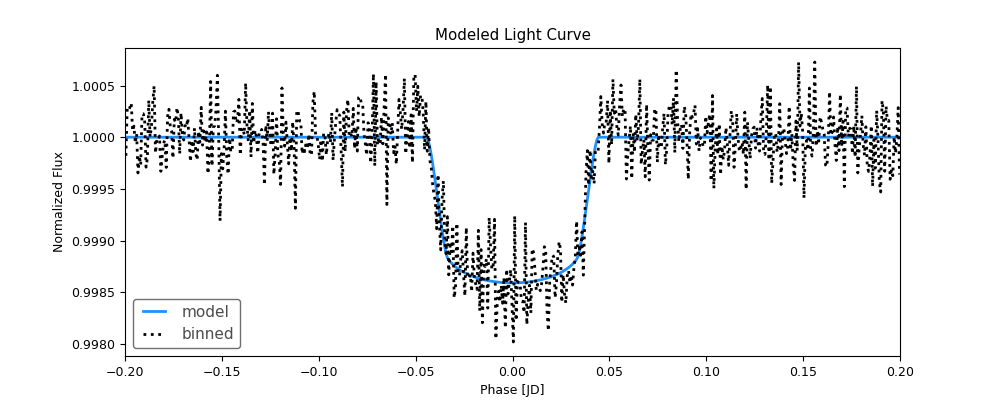

In [15]:
def initial_estimates(exoplanet, star):
    rad_est = (exoplanet['radius'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    inc_est = 90
    ecc_est = 0
    w_est = 90
    estimates = [rad_est, inc_est, ecc_est, w_est]
    lower_bounds = [rad_est-0.02,80,0,0]
    upper_bounds = [rad_est+0.02,90,0.999,180]
    return estimates, lower_bounds, upper_bounds
    
def batman_fun(x, exoplanet, star):
    params = batman.TransitParams()
    params.t0 = 0
    params.per = exoplanet['period'].value
    params.rp = x[0]
    params.a = (exoplanet['semimajor_axis'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    params.inc = x[1]
    params.ecc = x[2]
    params.w = x[3]
    params.limb_dark = 'nonlinear'
    params.u = [0.5,0.1,0.1,-0.1]  
    
    phase_min = min(exoplanet['light_curve'].phase.value)
    phase_max = max(exoplanet['light_curve'].phase.value)
    phase_len = len(exoplanet['light_curve'].flux.value)
    time = np.linspace(phase_min, phase_max, phase_len)
                       
    model = batman.TransitModel(params,time)
    batman_flux = model.light_curve(params)
    return batman_flux

def calc_residuals(x, exoplanet, star):
    observed = exoplanet['light_curve'].flux.value
    observed_error = exoplanet['light_curve'].flux_err.value
    modeled = batman_fun(x, exoplanet, star)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def plot_model(each, star):
    batman_flux = batman_fun(results.x, each, star)
    phase = each['light_curve'].phase.value

    fig, ax = plt.subplots(figsize = (10,4))
    ax.plot(phase, batman_flux, linewidth = '2', color = 'dodgerblue', label = 'model')
    each['light_curve'].plot(ax = ax, linewidth = '2', linestyle = ':', color = 'black', label = 'binned')
    plt.title('Modeled Light Curve')
    plt.xlim(-0.2,0.2)
    plt.show()

for each in exoplanets:
    estimates, lower_bounds, upper_bounds = initial_estimates(each, star)
    results = least_squares(calc_residuals, estimates, bounds = (lower_bounds, upper_bounds), args = (each, star,))

    each['radius'] = (results.x[0]*star['rad'][0]*u.Rsun).to(u.Rearth)
    each['inclination'] = results.x[1]*u.degree
    each['eccentricity'] = results.x[2]
    each['arg_periapsis'] = results.x[3]*u.degree
    print(f'Radius: {round(each['radius'],4)}')
    print(f'Inclination: {round(each['inclination'],4)}')
    print(f'Eccentricity: {round(each['eccentricity'],4)}')
    print(f'Argument of Periapsis (ω): {round(each['arg_periapsis'],4)}')

    plot_model(each, star)
    each.pop('light_curve')

In [16]:
for each in exoplanets:
    b1 = ((each['semimajor_axis']*np.cos(each['inclination'].to(u.radian)))/((star['rad'][0]*u.Rsun).to(u.au)))
    b2 = ((1-np.square(each['eccentricity']))/(1+(np.square(each['eccentricity'])*np.sin(each['arg_periapsis'].to(u.radian)))))

    each['impact_parameter'] = b1*b2
    print(f'Impact Parameter: {round(each['impact_parameter'],4)}')

Impact Parameter: 0.8454


### Radial Velocity Method

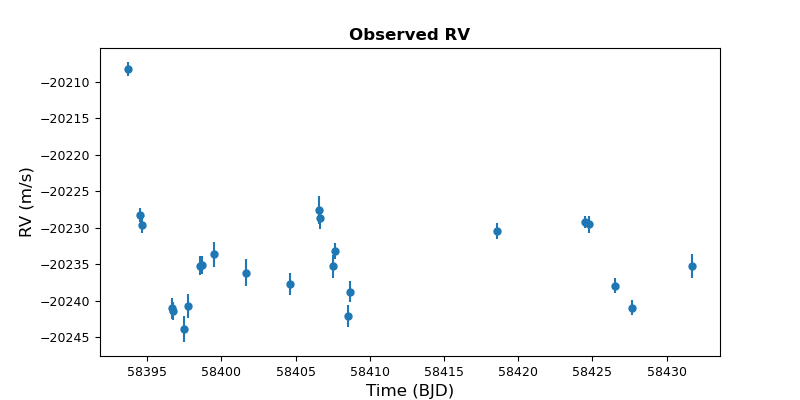

In [17]:
def plot_rv(rv_time, rv, rv_err):
    fig, ax = plt.subplots(figsize = (8,4))
    ax.errorbar(rv_time, rv, rv_err, fmt= 'o')
    ax.set_xlabel('Time (BJD)', fontsize = 12)
    ax.set_ylabel('RV (m/s)', fontsize = 12)

def import_harps():
    rv_ts = Spectroscopy.get_timeseries(input_catalog, sorted_by_instrument = True)

    index = []
    for each in rv_ts.keys():
        if each.find('HARPS15') != -1:
            index.append(each)
        elif each.find('HARPS') != -1:
            index.append(each)
    index1 = index[0]
    index2 = list(rv_ts[index1])[0]
    index3 = list(rv_ts[index1][index2])[0]
    rv_data = rv_ts[index1][index2][index3]
    rv_time, rv, rv_err = rv_data['rjd'], rv_data['rv'], rv_data['rv_err'] 
    
    plot_rv(rv_time, rv, rv_err)
    plt.title('Observed RV', fontsize = 12, fontweight = 'bold')
    
    rv_norm = (rv - np.median(rv))    
    sigma2 = 2*np.std(rv_norm)    
    
    i = 0 
    while i < len(rv_norm):
        if (rv_norm[i] > sigma2) or (rv_norm[i] < -sigma2):
            rv_time = np.delete(rv_time, i)
            rv_norm = np.delete(rv_norm, i)
            rv_err = np.delete(rv_err, i)
        i += 1
    return input_catalog, rv_time, rv_norm, rv_err

input_catalog, rv_time, rv_norm, rv_err = import_harps()

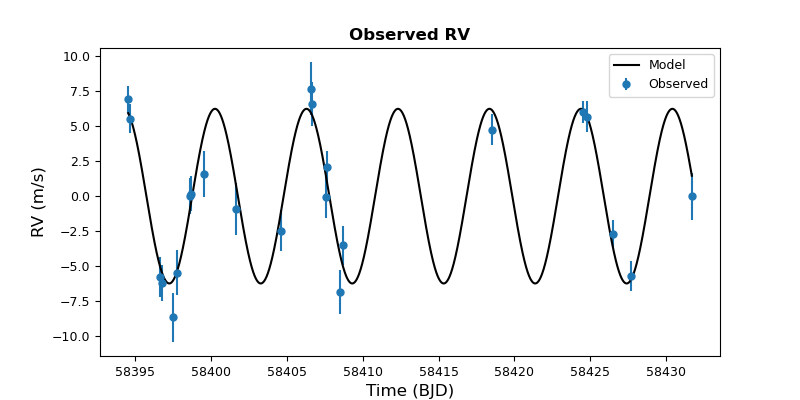

In [18]:
def initial_estimates():
    k_est = np.std(rv_norm)
    t0_est = 0
    #ecc_est = eccentricity
    estimates = [k_est, t0_est]
    return estimates

def rv_model(x, period):
    ecc = 0
    gamma = 0
    omega = np.pi/2
    true_anomaly = radvel.orbit.true_anomaly(rv_time, x[1], period, ecc)
    modeled = gamma + x[0]*((ecc*np.cos(omega)) + (np.cos(true_anomaly+(omega))))
    return modeled
    
def calc_residuals(x, period):
    observed = rv_norm
    observed_error = rv_err
    modeled = rv_model(x, period)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def final_model(period):
    model_x = np.linspace(np.min(rv_time), np.max(rv_time), 10000)
    ecc = 0
    gamma = 0
    omega = np.pi/2
    true_anomaly = radvel.orbit.true_anomaly(model_x, t0, period, 0)
    model_y = gamma + k*((ecc*np.cos(omega)) + (np.cos(true_anomaly+(omega))))
    return model_x, model_y

def plot_model(period):    
    plot_rv(rv_time, rv_norm, rv_err)
    model_x, model_y = final_model(period)
    plt.plot(model_x, model_y, color = 'black')
    plt.title('Observed RV', fontsize = 12, fontweight = 'bold')
    plt.legend(['Model', 'Observed'])

for each in exoplanets:
    estimates = initial_estimates()
    results = least_squares(calc_residuals, estimates, args = (each['period'].value,))
    k = results.x[0]
    each['semiamplitude'] = k*u.m/u.s
    t0 = results.x[1]
    each['rv_t0'] = t0
    plot_model(each['period'].value)

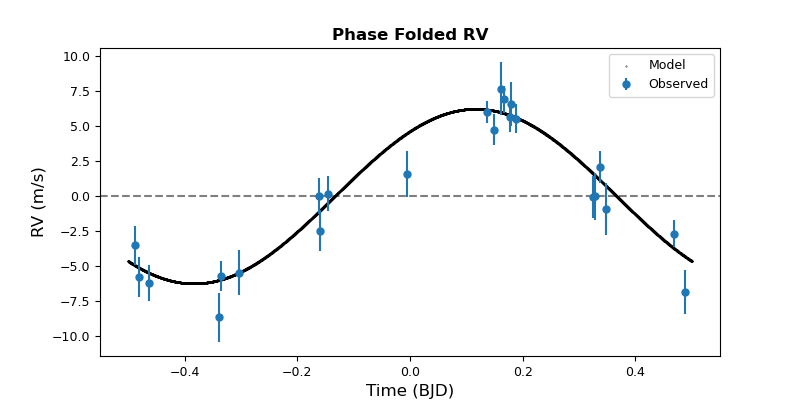

In [19]:
def plot_folded_rv(period):
    phase_time = ((rv_time%period)/period)-.5
    plot_rv(phase_time, rv_norm, rv_err)
    model_x, model_y = final_model(period)
    folded_model_x = ((model_x%period)/period)-.5
    plt.scatter(folded_model_x, model_y, color = 'black', s = .1, marker = 'o')
    plt.title('Phase Folded RV', fontsize = 12, fontweight = 'bold')
    plt.legend(['Model', 'Observed'])
    plt.axhline(0, linestyle = '--', alpha = .5, color = 'black')

for each in exoplanets:
    plot_folded_rv(each['period'].value)

In [20]:
def calc_mass(period, inclination):
    m1 = (period*u.day.to(u.s)*u.s)/(2*np.pi*const.G)
    m2 = k*u.m/u.s
    m3 = star['mass'][0]*u.M_sun.to(u.kg)*u.kg
    m4 = 1    #1-(eccentricity**2)
    d1 = np.sin(np.deg2rad(inclination))
    mass = ((m1**(1/3)) * m2 * (m3**(2/3)) * (m4**(1/2)))/d1
    mass_E = mass.to(u.Mearth)
    mass_J = mass.to(u.Mjupiter)

    if mass_E < 2*u.Mearth:
        exo_class = 'Terrestrial'
    elif mass_E < 10*u.Mearth:
        exo_class = 'Super-Earth'
    elif mass_E < 15*u.Mearth:
        exo_class = 'Sub-Neptune'
    elif mass_E < 150*u.Mearth:
        exo_class = 'Neptunian'
    elif mass_J < 13*u.Mjupiter:
        exo_class = 'Jovian'
    else:
        exo_class = 'Brown Dwarf'
    
    print(f'Mass: {round(mass_E, 4)}')
    print(f'Mass: {round(mass_J, 4)}')
    print(f'Class: {exo_class}')
    return mass_E, mass_J, exo_class

for each in exoplanets:
    mass_E, mass_J, exo_class = calc_mass(each['period'].value, each['inclination'].value)
    each['mass_E'], each['mass_J'], each['exo_class'] = mass_E, mass_J, exo_class

Mass: 17.4454 earthMass
Mass: 0.0549 jupiterMass
Class: Neptunian


In [21]:
def calc_bulk_density(mass, radius):
    volume = (4/3)*np.pi*((radius.to(u.cm))**3)
    mass_g = mass.to(u.g)
    bulk_density = mass_g/volume
    if bulk_density.value < 3:    
        composition = 'Ice/Gas' 
    elif bulk_density.value < 20:    
        composition = 'Iron/Rock'
    else:   
        composition = 'Degenerate'
        
    print(f'Bulk Density: {round(bulk_density, 4)}')
    print(f'Composition: {composition}')
    return bulk_density, composition

def calc_surf_grav(mass, radius):
    mass_kg = mass.to(u.kg)
    radius_m = radius.to(u.m)
    surf_grav = (const.G*mass_kg)/(radius_m**2)
    print(f'Surface Gravity: {round(surf_grav, 4)}')
    return surf_grav

for each in exoplanets:
    bulk_density, composition = calc_bulk_density(each['mass_E'], each['radius'])
    each['bulk_density'] = bulk_density
    each['composition'] = composition
    
    surf_grav = calc_surf_grav(each['mass_E'], each['radius'])
    each['surf_grav'] = surf_grav

Bulk Density: 1.108 g / cm3
Composition: Ice/Gas
Surface Gravity: 8.7385 m / s2


In [22]:
for exoplanet in exoplanets:
    for each in exoplanet:
        try:
            if type(exoplanet[each]) == str:
                print(f'{each}: {exoplanet[each]}')
            else:
                print(f'{each}: {round(exoplanet[each], 4)}')
        except:
            print(f'{each}: {round(float(exoplanet[each].value), 4)}')

stellar_class: G-Type Yellow Dwarf
period: 6.0346 d
duration: 0.0737 d
transit_t0: 3887.8144
depth: 0.002
snr: 20.273
radius: 4.4228 earthRad
semimajor_axis: 0.0642 AU
habitability: too hot
inclination: 86.3082 deg
eccentricity: 0.0
arg_periapsis: 47.8176 deg
impact_parameter: 0.8454
semiamplitude: 6.2402 m / s
rv_t0: -0.8058
mass_E: 17.4454 earthMass
mass_J: 0.0549 jupiterMass
exo_class: Neptunian
bulk_density: 1.108 g / cm3
composition: Ice/Gas
surf_grav: 8.7385 m / s2


#### Ideas for improvement
- output results to external storage/spreadsheet
- compare results with exoplanet archive
- test robustness
- add uncertainty margins
- refine transit & rv model
- test false positives
- imporove detection for longer periods
- transit timing variations
- atmospheric spectroscopy
- demonstrate doppler shift
- astrometry method